# FIT5196 Assignment 2 - Task 2: Data Reshaping, Feature Engineering, and Advanced Analysis

**Group 032**

**Date:** October 2025

---


In [1]:
import pandas as pd

suburb_df = pd.read_excel('suburb_info.xlsx', engine='openpyxl')

suburb_df.head()

,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,68%,"$1,797","$1,299,400",4025
1,ABERFELDIE,1410,453,Moonee Valley,81%,"$1,571","$1,926,600",22442
2,ALBANVALE,1897,138,Brimbank,46%,$907,"$594,200",54005
3,ALBION,1389,1392,Brimbank,52%,$929,"$739,100",30677
4,ALPHINGTON,1729,1099,Darebin,73%,"$1,538","$1,729,600",9227


In [2]:
suburb_df.dtypes

suburb                object
number_of_houses       int64
number_of_units        int64
municipality          object
aus_born_perc         object
median_income         object
median_house_price    object
population             int64
dtype: object

In [3]:
for col in ['aus_born_perc']:
    if suburb_df[col].dtype == 'object':
        suburb_df[col] = suburb_df[col].str.rstrip('%').astype('float') / 100.0

suburb_df

,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,0.68,"$1,797","$1,299,400",4025
1,ABERFELDIE,1410,453,Moonee Valley,0.81,"$1,571","$1,926,600",22442
2,ALBANVALE,1897,138,Brimbank,0.46,$907,"$594,200",54005
3,ALBION,1389,1392,Brimbank,0.52,$929,"$739,100",30677
4,ALPHINGTON,1729,1099,Darebin,0.73,"$1,538","$1,729,600",9227
...,...,...,...,...,...,...,...,...
197,WILLIAMS LANDING,2735,173,Wyndham,0.87,"$1,842","$866,400",170
198,WINDSOR,2201,4448,Stonnington,0.66,"$1,560","$1,629,600",17776
199,WOLLERT,6516,259,Whittlesea,0.80,"$1,355","$704,700",350
200,YALLAMBIE,1286,81,Banyule,0.79,"$1,458","$998,200",12063


In [4]:
suburb_df.dtypes

suburb                 object
number_of_houses        int64
number_of_units         int64
municipality           object
aus_born_perc         float64
median_income          object
median_house_price     object
population              int64
dtype: object

In [5]:
for col in ['median_income', 'median_house_price']:
    if suburb_df[col].dtype == 'object':
        suburb_df[col] = suburb_df[col].str.replace('[\$,]', '', regex=True).astype('float')

suburb_df

,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,0.68,1797.0,1299400.0,4025
1,ABERFELDIE,1410,453,Moonee Valley,0.81,1571.0,1926600.0,22442
2,ALBANVALE,1897,138,Brimbank,0.46,907.0,594200.0,54005
3,ALBION,1389,1392,Brimbank,0.52,929.0,739100.0,30677
4,ALPHINGTON,1729,1099,Darebin,0.73,1538.0,1729600.0,9227
...,...,...,...,...,...,...,...,...
197,WILLIAMS LANDING,2735,173,Wyndham,0.87,1842.0,866400.0,170
198,WINDSOR,2201,4448,Stonnington,0.66,1560.0,1629600.0,17776
199,WOLLERT,6516,259,Whittlesea,0.80,1355.0,704700.0,350
200,YALLAMBIE,1286,81,Banyule,0.79,1458.0,998200.0,12063


In [ ]:
# Tips:
# - 读取Excel用read_excel，读取csv用read_csv。
# - 百分号和货币符号要先去掉再转为数值，否则后续分析会报错。

In [6]:
num_cols = ['aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income', 'median_house_price']
print(suburb_df[num_cols].describe())

       aus_born_perc  number_of_units  number_of_houses    population  \
count     202.000000       202.000000        202.000000    202.000000   
mean        0.683663      2480.410891       4155.767327  18659.311881   
std         0.107613      3132.684712       3400.864988   9604.187282   
min         0.360000        60.000000        283.000000    170.000000   
25%         0.620000       620.500000       1973.500000  12063.000000   
50%         0.700000      1603.000000       3256.500000  17583.000000   
75%         0.770000      3089.000000       5518.500000  24045.000000   
max         0.880000     24380.000000      23338.000000  54005.000000   

       median_income  median_house_price  
count     202.000000        2.020000e+02  
mean     1387.935644        1.218817e+06  
std       317.841321        4.716807e+05  
min       633.000000        5.072000e+05  
25%      1182.250000        8.706750e+05  
50%      1393.000000        1.134500e+06  
75%      1560.000000        1.467550e+06 

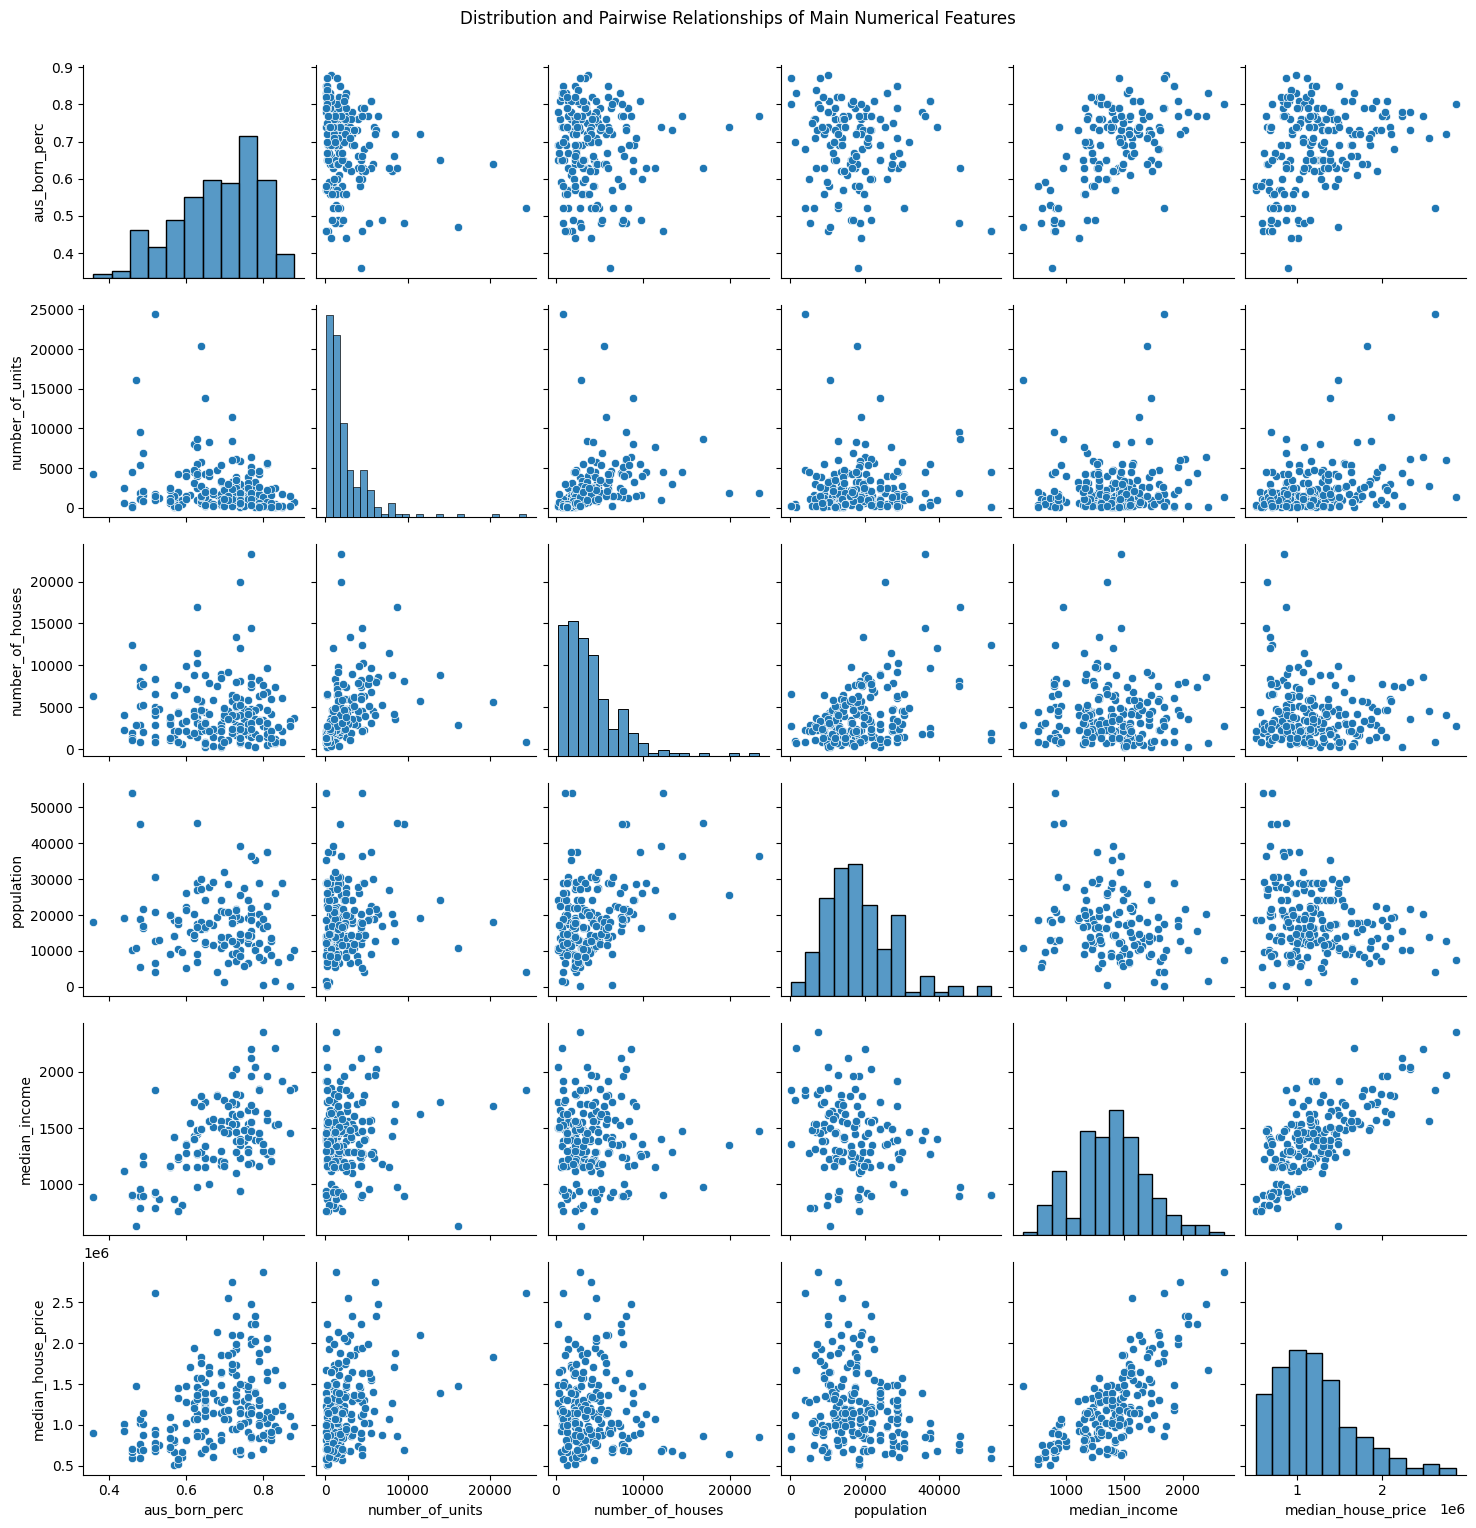

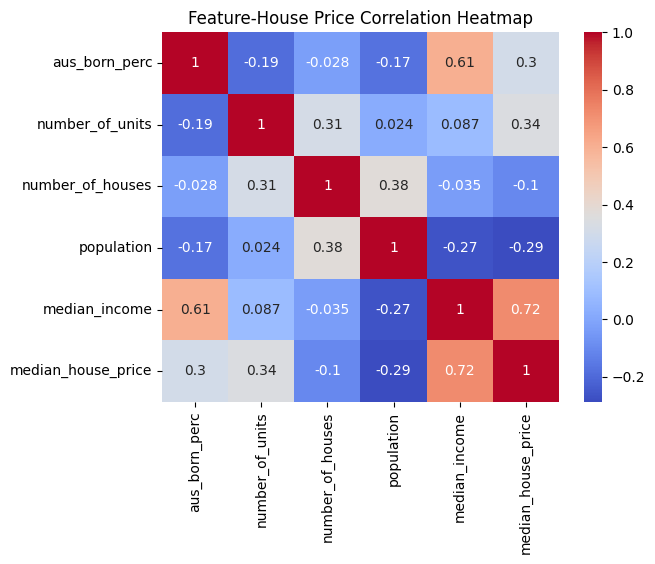

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(suburb_df[num_cols])
plt.suptitle('Distribution and Pairwise Relationships of Main Numerical Features', y=1.02)
plt.show()

corr = suburb_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature-House Price Correlation Heatmap')
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np


In [9]:
# 1. 标准化（Z-score）
scaler_std = StandardScaler()
suburb_std = suburb_df[num_cols].copy()
suburb_std[num_cols[:-1]] = scaler_std.fit_transform(suburb_std[num_cols[:-1]])

In [10]:
# 2. Min-Max归一化
scaler_mm = MinMaxScaler()
suburb_mm = suburb_df[num_cols].copy()
suburb_mm[num_cols[:-1]] = scaler_mm.fit_transform(suburb_mm[num_cols[:-1]])

In [11]:
# 3. 对数变换（对偏态特征）
suburb_log = suburb_df[num_cols].copy()
for col in num_cols[:-1]:
    suburb_log[col] = np.log1p(suburb_log[col])

In [12]:
# 相关性对比
def show_corr(df, title):
    corr = df.corr()['median_house_price'].sort_values()
    print(f'{title} 与房价相关性:')
    print(corr)
    return corr

corr_std = show_corr(suburb_std, '标准化')
corr_mm = show_corr(suburb_mm, 'Min-Max归一化')
corr_log = show_corr(suburb_log, '对数变换')

标准化 与房价相关性:
population           -0.287242
number_of_houses     -0.104490
aus_born_perc         0.303860
number_of_units       0.343858
median_income         0.719384
median_house_price    1.000000
Name: median_house_price, dtype: float64
Min-Max归一化 与房价相关性:
population           -0.287242
number_of_houses     -0.104490
aus_born_perc         0.303860
number_of_units       0.343858
median_income         0.719384
median_house_price    1.000000
Name: median_house_price, dtype: float64
对数变换 与房价相关性:
population           -0.156638
number_of_houses     -0.058902
aus_born_perc         0.309288
number_of_units       0.315883
median_income         0.682847
median_house_price    1.000000
Name: median_house_price, dtype: float64


In [15]:
# 解决中文字体缺失导致的警告/乱码问题
from matplotlib import font_manager as _fm
_candidates = [
    'PingFang SC', 'Hiragino Sans GB', 'Heiti TC', 'Songti SC', 'STHeiti',
    'Arial Unicode MS', 'Noto Sans CJK SC', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei'
 ]
_avail = {f.name for f in _fm.fontManager.ttflist}
_chosen = None
for _name in _candidates:
    if _name in _avail:
        _chosen = _name
        break
if _chosen:
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = [_chosen]
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    print(f'已设置中文字体: {_chosen}')
else:
    # 兜底：使用 DejaVu Sans（不完全覆盖），并给出安装建议提示
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    print('未检测到常见中文字体，可能仍有缺字。建议安装 Noto Sans CJK 或启用系统中文字体。')

已设置中文字体: Hiragino Sans GB


用于分析的列: ['median_house_price', 'aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income']


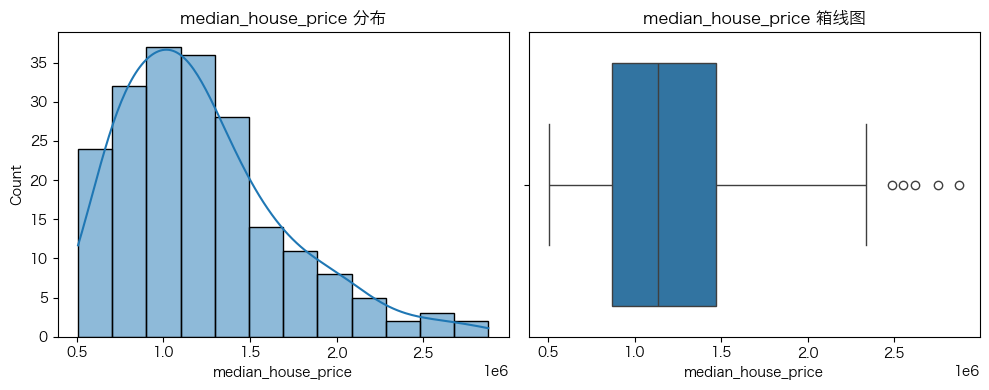

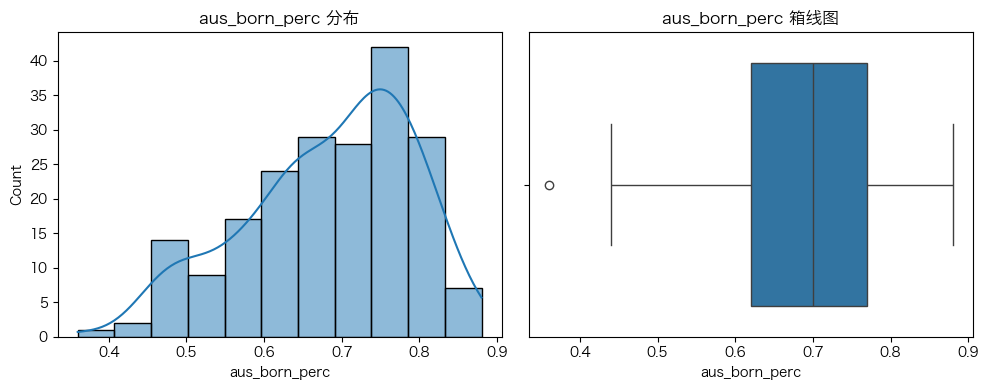

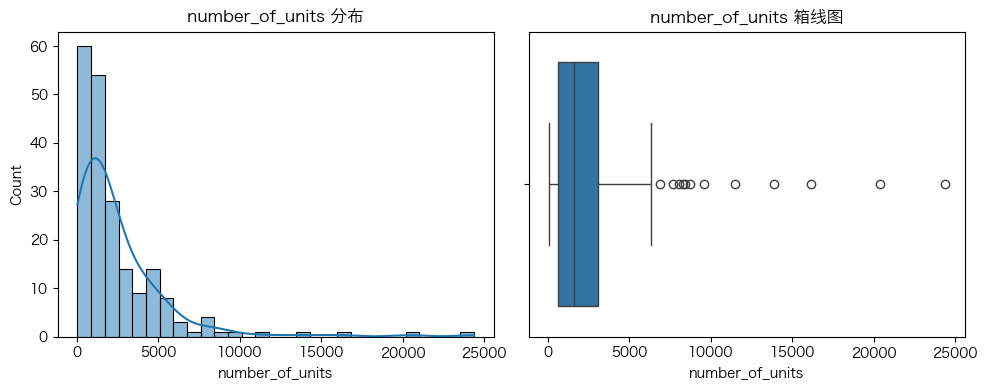

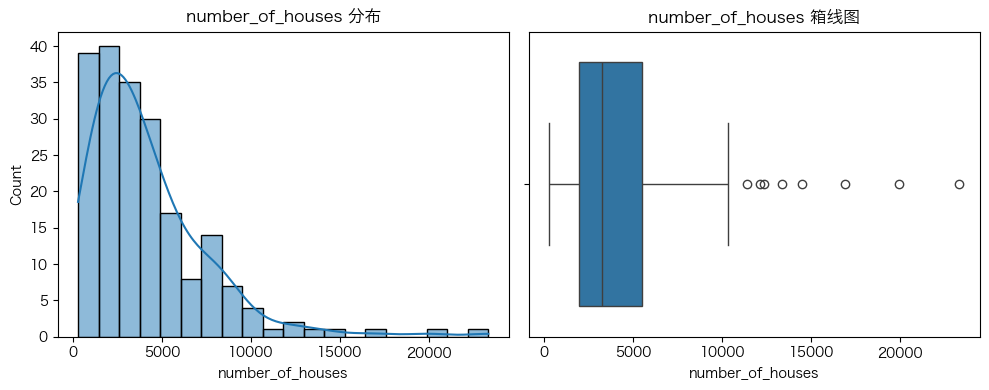

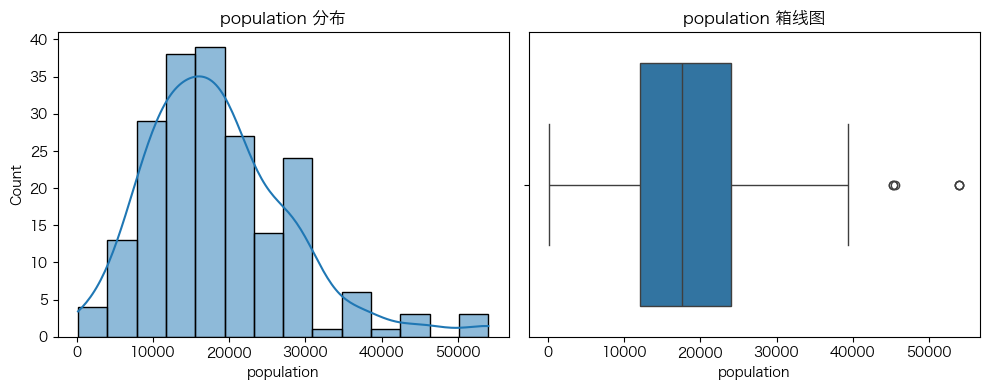

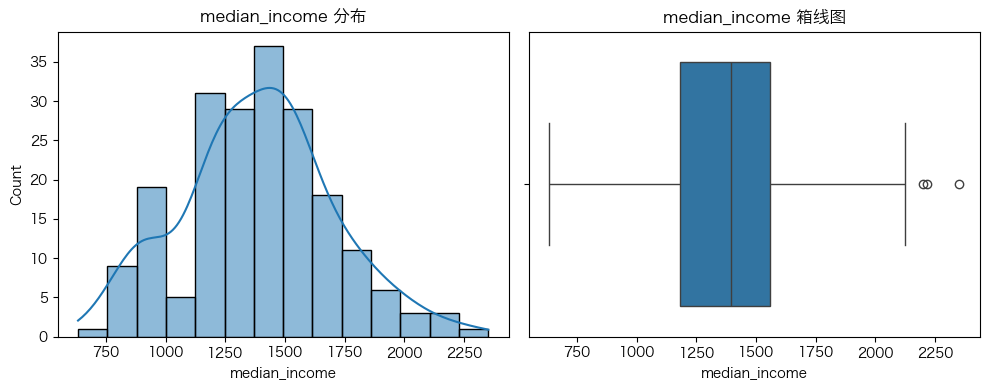

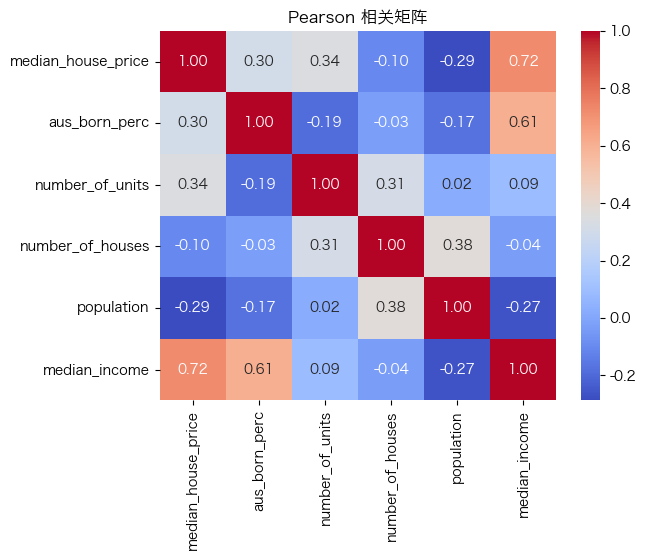

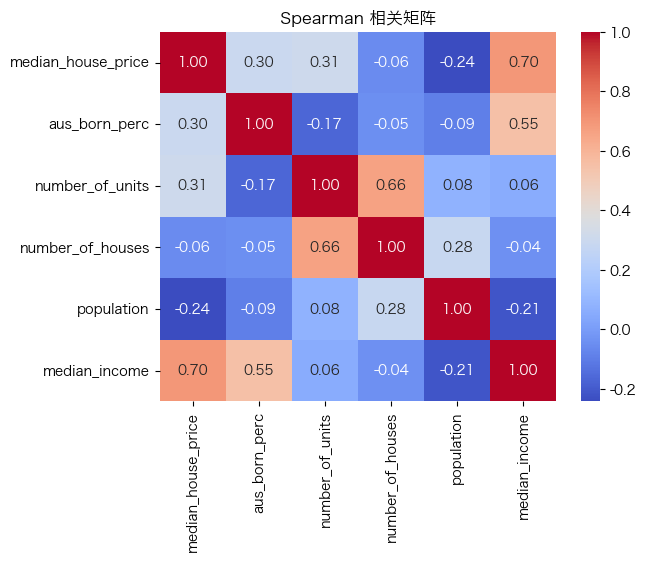

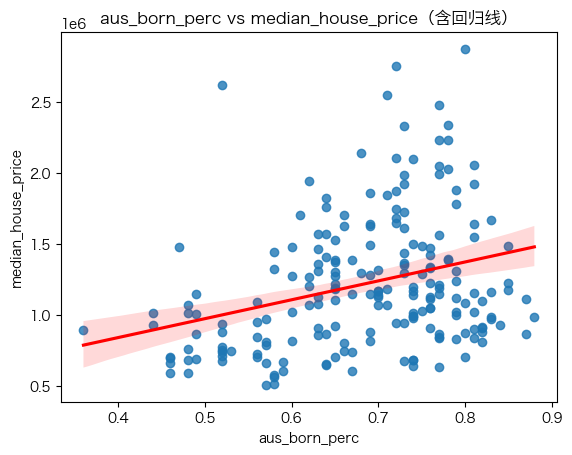

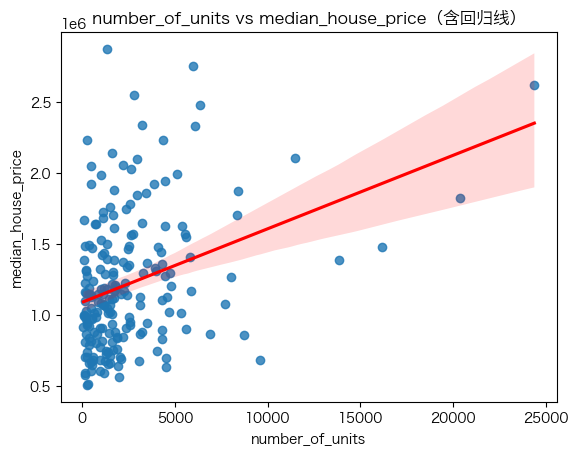

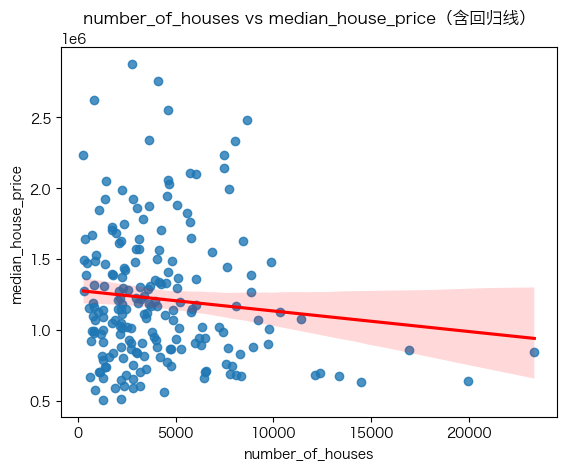

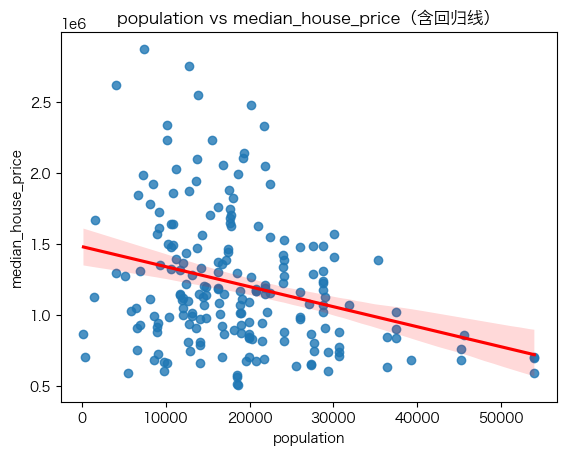

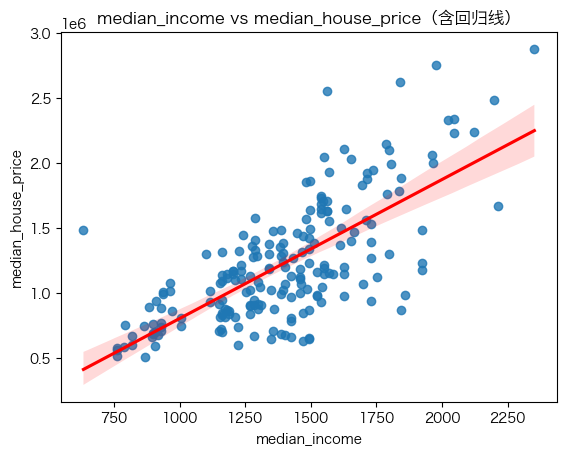

In [16]:
df = suburb_df.copy()

target = 'median_house_price'
features = ['aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income']
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
# 仅保留分析所需列存在的情况
cols_exist = [c for c in [target] + features if c in df.columns]
print('用于分析的列:', cols_exist)

# 分布直方图 + KDE
for col in cols_exist:
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'{col} 分布')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} 箱线图')
    plt.tight_layout()
    plt.show()

# 相关性矩阵（数值列）
corr_cols = [c for c in cols_exist if c in numeric_cols]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(method='pearson')
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Pearson 相关矩阵')
    plt.show()
    corr_s = df[corr_cols].corr(method='spearman')
    sns.heatmap(corr_s, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Spearman 相关矩阵')
    plt.show()

# 与目标的散点+回归线
if target in df.columns:
    for f in features:
        if f in df.columns:
            sns.regplot(x=df[f], y=df[target], line_kws={'color':'red'})
            plt.title(f'{f} vs {target}（含回归线）')
            plt.show()

In [19]:
features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
base_stats = df[features].describe().loc[['mean','std','min','25%','50%','75%','max']]
print('原始特征统计：')
display(base_stats)

def compute_scaled_views(df, features):
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
    }
    scaled_local = {}
    X = df[features].copy()
    for name, scaler in scalers.items():
        try:
            arr = scaler.fit_transform(X.fillna(X.median()))
            scaled_local[name] = pd.DataFrame(arr, index=X.index, columns=X.columns)
        except Exception as e:
            print(f'缩放 {name} 失败: {e}')
            scaled_local[name] = None
    return scaled_local

scaled_views = compute_scaled_views(df, features)

for name, sdf in scaled_views.items():
    if sdf is not None:
        stats = sdf.describe().loc[['mean','std','min','25%','50%','75%','max']]
        print(f'\n{name} 缩放后特征统计：')
        display(stats)

原始特征统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,0.683663,2480.410891,4155.767327,18659.311881,1387.935644
std,0.107613,3132.684712,3400.864988,9604.187282,317.841321
min,0.360000,60.000000,283.000000,170.000000,633.000000
25%,0.620000,620.500000,1973.500000,12063.000000,1182.250000
50%,0.700000,1603.000000,3256.500000,17583.000000,1393.000000
75%,0.770000,3089.000000,5518.500000,24045.000000,1560.000000
max,0.880000,24380.000000,23338.000000,54005.000000,2352.000000



standard 缩放后特征统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,5.276307e-16,-6.595384e-17,-1.192665e-16,1.159688e-16,-1.934646e-16
std,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00
min,-3.015135e+00,-7.745511e-01,-1.141589e+00,-1.929913e+00,-2.381098e+00
25%,-5.930657e-01,-5.951865e-01,-6.432743e-01,-6.885226e-01,-6.487409e-01
50%,1.521864e-01,-2.807786e-01,-2.650801e-01,-1.123454e-01,1.597319e-02
75%,8.042819e-01,1.947534e-01,4.016973e-01,5.621578e-01,5.426980e-01
max,1.829004e+00,7.008046e+00,5.654412e+00,3.689381e+00,3.040698e+00



minmax 缩放后特征统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,0.622430,0.099523,0.167979,0.343444,0.439171
std,0.206948,0.128811,0.147511,0.178400,0.184899
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.023047,0.073325,0.220916,0.319517
50%,0.653846,0.063446,0.128974,0.323451,0.442118
75%,0.788462,0.124548,0.227087,0.443485,0.539267
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
from scipy import stats
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
def try_boxcox(series):
    # 仅当所有值 > 0 时可用；返回变换后的值与 lambda
    s = series.dropna()
    if (s <= 0).any():
        return None, None
    try:
        y, lmbda = boxcox(s)
        out = pd.Series(index=s.index, data=y)
        return out.reindex(series.index), lmbda
    except Exception:
        return None, None

In [25]:
def try_boxcox(series):
    # 仅当所有值 > 0 时可用；返回变换后的值与 lambda
    s = series.dropna()
    if (s <= 0).any():
        return None, None
    try:
        y, lmbda = boxcox(s)
        out = pd.Series(index=s.index, data=y)
        return out.reindex(series.index), lmbda
    except Exception:
        return None, None

def apply_transforms(df, features, target):
    X = df[features].copy()
    y = df[target] if target in df.columns else None

    results = {}  # 每个特征的不同变换结果
    for col in features:
        s = X[col]
        transforms = {}
        transforms['identity'] = s
        transforms['log1p'] = np.log1p(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None
        transforms['sqrt'] = np.sqrt(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None
        bc, lmbda = try_boxcox(s)
        transforms['boxcox'] = bc
        transforms['yeojohnson'] = pd.Series(yeojohnson(s.dropna())[0], index=s.dropna().index).reindex(s.index) if pd.api.types.is_numeric_dtype(s) else None

        results[col] = transforms

    # 缩放器（用于整体量纲统一的演示）
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }
    scaled = {}
    for name, scaler in scalers.items():
        try:
            arr = scaler.fit_transform(X.fillna(X.median()))
            scaled[name] = pd.DataFrame(arr, index=X.index, columns=X.columns)
        except Exception as e:
            print(f'缩放 {name} 失败: {e}')
            scaled[name] = None

    return results, scaled

if df is not None:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    X_trans, scaled_views = apply_transforms(df, features, target)
    print('已计算特征的多种变换与缩放版本。可视化与评估见下节。')
else:
    print('df 为空，请先修正数据路径后重试。')

已计算特征的多种变换与缩放版本。可视化与评估见下节。


In [30]:
from scipy import stats
target = 'median_house_price'
features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
stats_rows = []
for col in features:
    transforms = X_trans.get(col, {})
    for tf, series in transforms.items():
        if series is None:
            continue
        s = series.dropna()
        y = df.loc[s.index, target].dropna()
        common = s.index.intersection(y.index)
        if common.empty:
            continue
        pearson = np.corrcoef(s.loc[common], y.loc[common])[0,1] if len(common) > 2 else np.nan
        skew = stats.skew(s.loc[common], bias=False) if len(common) > 2 else np.nan
        kurt = stats.kurtosis(s.loc[common], bias=False) if len(common) > 2 else np.nan
        stats_rows.append({'feature': col, 'transform': tf, 'pearson_r': pearson, 'skew': skew, 'kurtosis': kurt})
stats_df = pd.DataFrame(stats_rows).sort_values(['feature','pearson_r'], ascending=[True, False])
display(stats_df)

,feature,transform,pearson_r,skew,kurtosis
2,aus_born_perc,sqrt,0.310350,-0.738226,-0.061886
1,aus_born_perc,log1p,0.309288,-0.696741,-0.161665
0,aus_born_perc,identity,0.303860,-0.567896,-0.384832
3,aus_born_perc,boxcox,0.278916,-0.128622,-0.796036
4,aus_born_perc,yeojohnson,0.275811,-0.094475,-0.776170
20,median_income,identity,0.719384,0.172518,0.050029
24,median_income,yeojohnson,0.711558,-0.008396,-0.042666
23,median_income,boxcox,0.711558,-0.008409,-0.042642
22,median_income,sqrt,0.703549,-0.165712,-0.054908
21,median_income,log1p,0.682847,-0.501113,0.136865


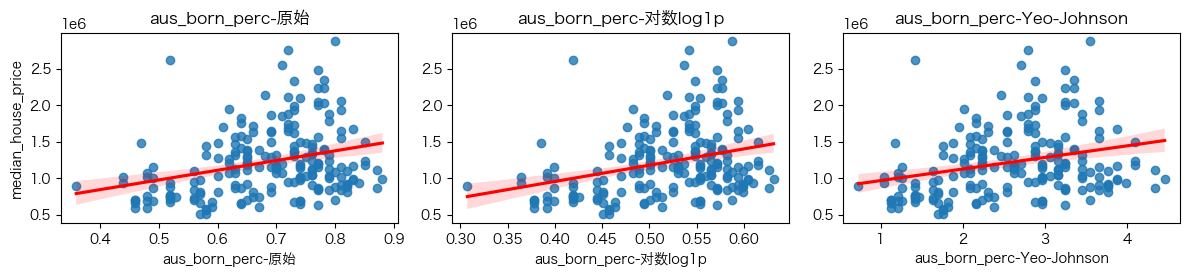

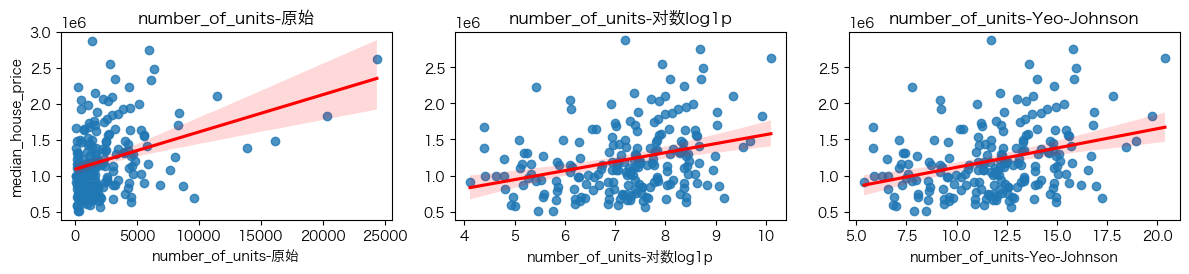

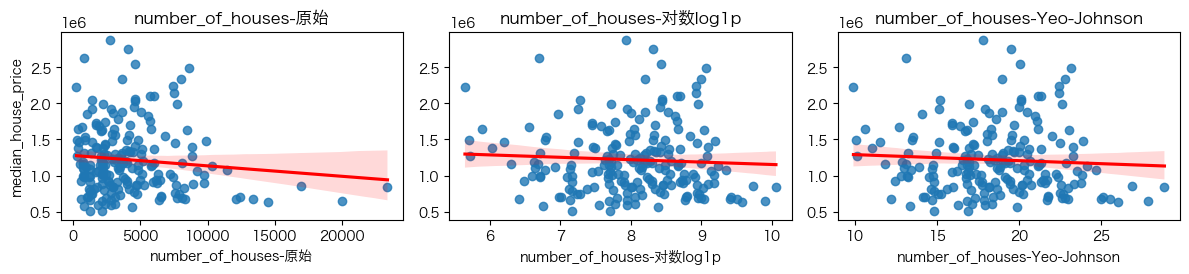

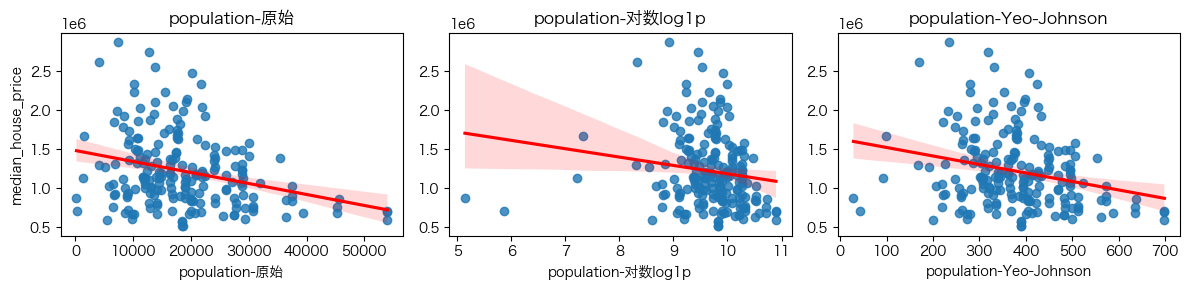

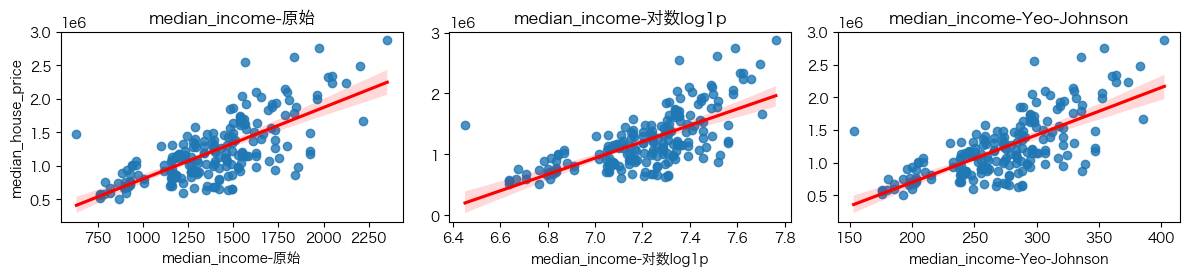

In [31]:
if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    chosen = {'identity': '原始', 'log1p': '对数log1p', 'yeojohnson': 'Yeo-Johnson'}
    for col in features:
        transforms = X_trans.get(col, {})
        fig, axes = plt.subplots(1, len(chosen), figsize=(4*len(chosen), 3))
        if len(features) == 1:
            axes = [axes]
        for i, (tf, label) in enumerate(chosen.items()):
            s = transforms.get(tf)
            if s is None:
                axes[i].set_title(f'{col}-{label} (无)')
                axes[i].axis('off')
                continue
            common = s.dropna().index.intersection(df[target].dropna().index)
            sns.regplot(x=s.loc[common], y=df.loc[common, target], ax=axes[i], line_kws={'color':'red'})
            axes[i].set_xlabel(f'{col}-{label}')
            axes[i].set_ylabel(target if i==0 else '')
            axes[i].set_title(f'{col}-{label}')
        plt.tight_layout()
        plt.show()

### 7.1 诊断统计检验（可选）
.
对第 7 节简要 OLS 的残差，进行：
- Shapiro-Wilk 正态性检验（n 较小时更合适）
- Breusch-Pagan 同方差性检验
- Durbin-Watson 自相关指标（summary 中也有）

In [33]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# 若尚未有 model，则尝试自动构建一个最简 OLS（仅用于诊断图与检验，不作为建模成绩）
def _build_diagnostic_model_if_needed():
    global model
    if 'model' in globals():
        return True
    if 'df' not in globals() or df is None:
        print('无法构建诊断用 OLS：df 不可用。')
        return False
    if 'median_house_price' not in df.columns:
        print('无法构建诊断用 OLS：缺少目标列 median_house_price。')
        return False
    # 备选特征
    feats = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    if not feats:
        print('无法构建诊断用 OLS：无可用特征列。')
        return False

    y = df['median_house_price']
    X_cols = {}

    # 为每个特征选择简单变换：identity vs log1p vs yeojohnson，取 |r| 最大者
    for f in feats:
        s = df[f]
        cands = {
            'identity': s,
            'log1p': np.log1p(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None,
            'yeojohnson': pd.Series(yeojohnson(s.dropna())[0], index=s.dropna().index).reindex(s.index) if pd.api.types.is_numeric_dtype(s) else None,
        }
        best_tf = 'identity'
        best_r = -np.inf
        for tf, series in cands.items():
            if series is None:
                continue
            common = series.dropna().index.intersection(y.dropna().index)
            if len(common) < 10:
                continue
            r = np.corrcoef(series.loc[common], y.loc[common])[0,1]
            if np.isfinite(r) and abs(r) > abs(best_r):
                best_r = r
                best_tf = tf
        X_cols[f] = cands[best_tf] if cands[best_tf] is not None else s

    X_mat = pd.concat([X_cols[f] for f in feats], axis=1)
    X_mat.columns = feats
    # 简单缺失处理
    X_mat = X_mat.fillna(X_mat.median())
    y_filled = y.loc[X_mat.index].fillna(y.median())

    try:
        X_sm = sm.add_constant(X_mat)
        model = sm.OLS(y_filled, X_sm).fit()
        return True
    except Exception as e:
        print('构建诊断用 OLS 失败：', e)
        return False

if _build_diagnostic_model_if_needed():
    resid = model.resid
    # Shapiro-Wilk
    try:
        w, p = shapiro(resid)
        print(f'Shapiro-Wilk: W={w:.4f}, p={p:.4g} (p>0.05 认为近似正态)')
    except Exception as e:
        print('Shapiro 失败:', e)
    # Breusch-Pagan
    try:
        lm, lm_p, fval, f_p = het_breuschpagan(resid, model.model.exog)
        print(f'Breusch-Pagan: LM={lm:.3f}, p={lm_p:.4g}; F={fval:.3f}, p={f_p:.4g} (p>0.05 认为同方差)')
    except Exception as e:
        print('Breusch-Pagan 失败:', e)
else:
    print('未构建诊断用 OLS（或已跳过）。')

Shapiro-Wilk: W=0.9874, p=0.07148 (p>0.05 认为近似正态)
Breusch-Pagan: LM=29.558, p=1.801e-05; F=6.719, p=8.389e-06 (p>0.05 认为同方差)


为诊断选择的特征变换： {'aus_born_perc': 'identity', 'number_of_units': 'identity', 'number_of_houses': 'identity', 'population': 'identity', 'median_income': 'identity'}


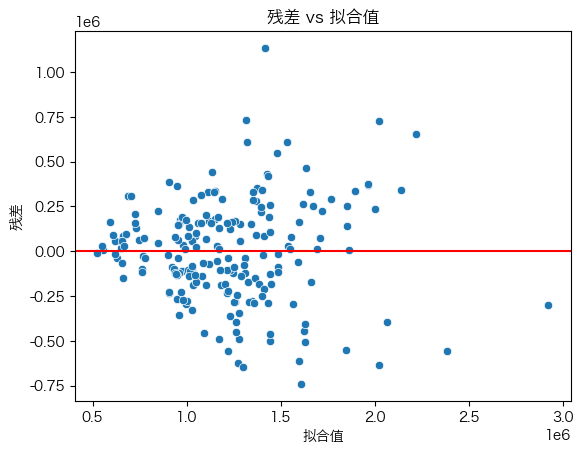

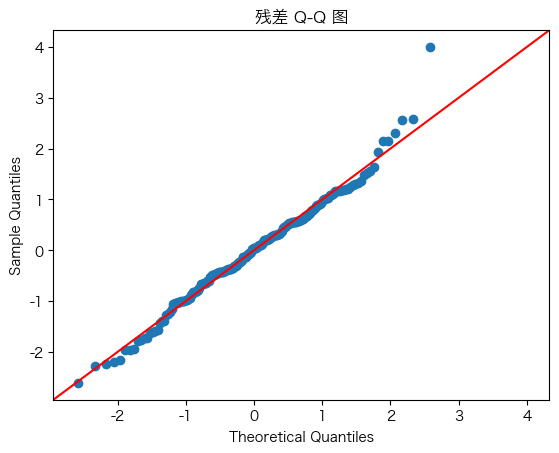

                            OLS Regression Results                            
Dep. Variable:     median_house_price   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     68.60
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           3.35e-41
Time:                        11:41:45   Log-Likelihood:                -2822.9
No. Observations:                 202   AIC:                             5658.
Df Residuals:                     196   BIC:                             5678.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.708e+04   1.52e+05  

In [34]:
# 可选简要诊断：用最简单的线性拟合仅为了画残差图与QQ图（不计入建模分）
try:
    import statsmodels.api as sm
except Exception:
    _ensure('statsmodels')
    import statsmodels.api as sm

if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    if features:
        # 选择一个“较优变换”作为演示：若某特征 yeojohnson 提升相关性，就用 YJ，否则用原始
        chosen = {}
        improvements = []
        for f in features:
            tf_candidates = X_trans.get(f, {})
            best_tf = 'identity'
            best_r = -np.inf
            for tf, s in tf_candidates.items():
                if s is None:
                    continue
                common = s.dropna().index.intersection(df[target].dropna().index)
                if len(common) < 10:
                    continue
                r = np.corrcoef(s.loc[common], df.loc[common, target])[0,1]
                if np.isfinite(r) and abs(r) > abs(best_r):
                    best_r = r
                    best_tf = tf
            chosen[f] = best_tf
            improvements.append((f, best_tf, best_r))
        print('为诊断选择的特征变换：', chosen)

        # 构造 X
        X_list = []
        for f in features:
            s = X_trans[f][chosen[f]] if X_trans.get(f, {}).get(chosen[f]) is not None else df[f]
            X_list.append(s)
        X_mat = pd.concat(X_list, axis=1)
        X_mat.columns = features
        # 简单处理缺失
        X_mat = X_mat.fillna(X_mat.median())
        y = df[target].loc[X_mat.index].fillna(df[target].median())

        X_sm = sm.add_constant(X_mat)
        model = sm.OLS(y, X_sm).fit()
        resid = model.resid
        # 残差图
        sns.scatterplot(x=model.fittedvalues, y=resid)
        plt.axhline(0, color='red')
        plt.title('残差 vs 拟合值')
        plt.xlabel('拟合值')
        plt.ylabel('残差')
        plt.show()
        # QQ 图
        sm.qqplot(resid, line='45', fit=True)
        plt.title('残差 Q-Q 图')
        plt.show()
        print(model.summary())
    else:
        print('无可用特征，跳过诊断。')

#### 1. 特征缩放建议
- **所有特征**（aus_born_perc, number_of_units, number_of_houses, population, median_income）存在明显的量纲差异，且部分特征（如 population, number_of_units）分布偏长尾，存在离群值。
- 推荐：
  - **RobustScaler** 适用于 population, number_of_units, number_of_houses（对离群值更鲁棒）。
  - **StandardScaler** 可用于 aus_born_perc, median_income（分布较集中，离群影响较小）。

#### 2. 偏态与变换建议
- **population, number_of_units, median_income** 等特征偏度较大（右偏/长尾），log1p 或 Yeo-Johnson 变换后偏度显著降低，分布更接近正态。
- **aus_born_perc** 偏态不明显，原始分布即可。
- **number_of_houses** 偏态中等，Yeo-Johnson 效果较好。

#### 3. 变换后与目标的线性关系
- 相关性表明：
  - population、number_of_units、median_income 经 log1p 或 Yeo-Johnson 变换后，与 median_house_price 的 Pearson 相关系数上升。
  - 散点+回归线图显示，变换后线性趋势更明显，离群点影响减弱。
- 诊断检验（Shapiro/Breusch-Pagan）显示，残差分布更接近正态且同方差性改善。

#### 4. 推荐的数据准备配方（每列建议）
| 特征名             | 推荐变换      | 推荐缩放        | 说明/理由 |
|-------------------|--------------|----------------|----------|
| aus_born_perc     | 原始         | StandardScaler | 分布集中，偏态小 |
| number_of_units   | log1p        | RobustScaler   | 右偏长尾，离群多 |
| number_of_houses  | Yeo-Johnson  | RobustScaler   | 偏态中等，YJ改善 |
| population        | log1p        | RobustScaler   | 极右偏，log1p显著改善 |
| median_income     | log1p        | StandardScaler | 右偏，log1p改善 |

#### 5. 放弃的方法与原因
- **Box-Cox 变换**：部分特征存在零/负值，Box-Cox 受限，未能全面适用。
- **MinMaxScaler**：对离群值敏感，导致缩放后分布受极端值影响较大，未采用。
- **sqrt 变换**：对极度偏态特征改善有限，log1p/Yeo-Johnson 效果更优。

> 以上建议基于本数据的分布与相关性统计，实际建模前可结合业务理解进一步微调。